<a href="https://colab.research.google.com/github/Evgeniya-Ryasnova/generative-mocap/blob/master/generative_mocap_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative MoCap Reproduction Study

## 0. Reproduction Notes

### Goals

* Set up the repository in Google Colab.
* Verify GPU availability.
* Run a short WS-cGAN test training.
* Run full WS-cGAN training.
* Reproduce training data, test data, and dimensionless walking speed analyses.
* Document Colab-specific compatibility fixes.

### Environment

* Google Colab
* NVIDIA Tesla T4
* Python 3.12
* PyTorch 2.x

### Dataset

* data/data_1.pickle
* data/data_2.pickle

# 1. Environment Setup

Verify the Python, PyTorch and CUDA configuration.

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
Tesla T4


# 2. Clone Repository

The forked GitHub repository is cloned into the Colab runtime.

In [3]:
!git clone https://github.com/Evgeniya-Ryasnova/generative-mocap.git


Cloning into 'generative-mocap'...
remote: Enumerating objects: 273, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 273 (delta 29), reused 0 (delta 0), pack-reused 220 (from 4)
Receiving objects: 100% (273/273), 1.38 GiB | 18.48 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Updating files: 100% (184/184), done.


# 3. Change Working Directory

The working directory is changed to the cloned repository so that Python can access the project scripts, datasets, and output folders correctly.

In [5]:
%cd generative-mocap

[Errno 2] No such file or directory: 'generative-mocap'
/content/generative-mocap


# 4. Install Dependencies

Install required packages.

In [6]:
!pip install spm1d ezc3d statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.3 MB/s eta 0:00:00


# 5. Verify Training Function

The main training function `train_cgan()` is imported and its function signature is inspected to understand which parameters can be changed for reproduction experiments.

In [ ]:
from train_cgans import train_cgan
import inspect

print(inspect.signature(train_cgan))

/content/generative-mocap/utils.py:486: SyntaxWarning: invalid escape sequence '\%'
  for i in [4, 5, 9]: axs[i].set_xlabel('Gait Cycle [\%]', fontsize=25)
/content/generative-mocap/utils.py:598: SyntaxWarning: invalid escape sequence '\%'
  for ax in axs[2:]: ax.set_xlabel('Gait Cycle [\%]', fontsize=25)


(marker_names=array(['L_IAS', 'L_IPS', 'R_IPS', 'R_IAS', 'R_FTC', 'R_FLE', 'R_FME',
       'R_FAX', 'R_TTC', 'R_FAL', 'R_TAM', 'R_FCC', 'R_FM1', 'R_FM2',
       'R_FM5'], dtype='<U5'), grf_names=array(['force', 'point', 'moment'], dtype='<U6'), ik_names=array(['pelvis_tilt', 'pelvis_list', 'pelvis_rotation', 'hip_flexion_r',
       'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r',
       'ankle_angle_r'], dtype='<U15'), value_cols=['marker_gc', 'grf_3d_gc', 'ik_gc'], names_cols=['marker_names', 'grf_names_3d', 'ik_names'], label_col_contd=['age'], label_col_discr=None, data_df_file=['data/data_1.pickle', 'data/data_2.pickle'], excluded_subjects=[2014001, 2014003, 2015042], z_dim=20, hidden_dim=512, n_epochs=3000, lr=0.002, batch_size=128, display_step=250, n_samples=10, label_contd_lims=[[15, 71, 1]], label_discr_lims=None, model_name='acgan', device=device(type='cuda'), seed=0)


# 6. Test WS-cGAN Training

A short WS-cGAN training run is performed with 10 epochs to verify that the full training pipeline works before running the full 3000-epoch experiment.

## Parameters

- n_epochs = 10
- display_step = 1
- model_name = "wscgan_test"
- condition = walking_speed

In [ ]:
from train_cgans import train_cgan
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_cgan(
    label_col_contd=['walking_speed'],
    label_col_discr=None,
    n_epochs=10,
    display_step=1,
    label_contd_lims=[[0.16, 2.41, 0.02]],
    label_discr_lims=None,
    model_name='wscgan_test',
    device=device,
    seed=0
)

/content/generative-mocap/train_cgans.py:390: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  valid = Tensor(real.shape[0], 1).fill_(1.0)


Epoch 1, step 1: Generator loss: 0.06170816719532013, discriminator loss: 0.6723203659057617
Epoch 1, step 2: Generator loss: 0.04478055238723755, discriminator loss: 0.6367135047912598
Epoch 1, step 3: Generator loss: 0.04045671224594116, discriminator loss: 0.650017499923706
Epoch 1, step 4: Generator loss: 0.02108882926404476, discriminator loss: 0.6738141775131226
Epoch 1, step 5: Generator loss: 0.016384847462177277, discriminator loss: 0.6306586265563965
Epoch 1, step 6: Generator loss: 0.012760194949805737, discriminator loss: 0.5233613848686218
Epoch 2, step 7: Generator loss: 0.009743797592818737, discriminator loss: 0.4933582544326782
Epoch 2, step 8: Generator loss: 0.00881848856806755, discriminator loss: 0.47737598419189453
Epoch 2, step 9: Generator loss: 0.00764224398881197, discriminator loss: 0.4228903353214264
Epoch 2, step 10: Generator loss: 0.006682139355689287, discriminator loss: 0.4684189558029175
Epoch 2, step 11: Generator loss: 0.00585491769015789, discrimina

# 7. Check Test Training Outputs

The output directory is inspected to confirm that the trained generator, synthetic data, and transformation files were saved successfully.

In [ ]:
!ls Results/wscgan_test

back_transform_input.pkl  synthetic_data_after_training.pkl
generator.pt		  transform_labels.pkl


# 8. Full WS-cGAN Training

The full WS-cGAN model is trained using the original number of epochs from the paper/code.

## Parameters

- n_epochs = 3000
- display_step = 250
- model_name = "wscgan"
- condition = walking_speed
- seed = 0

## Reproducibility settings

Random seed:

- seed = 0

The original implementation uses seed=0. The same value is retained to maximize reproducibility and facilitate comparison with the published results.

In [ ]:
from train_cgans import train_cgan
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_cgan(
    label_col_contd=['walking_speed'],
    label_col_discr=None,
    n_epochs=3000,
    display_step=250,
    label_contd_lims=[[0.16, 2.41, 0.02]],
    label_discr_lims=None,
    model_name='wscgan',
    device=device,
    seed=0
)

Epoch 42, step 250: Generator loss: 0.004184564739931375, discriminator loss: 0.5592460337281228
Epoch 84, step 500: Generator loss: 0.0016667985990643501, discriminator loss: 0.6674943280220031
Epoch 125, step 750: Generator loss: 0.0016533804787322878, discriminator loss: 0.6309146748781205
Epoch 167, step 1000: Generator loss: 0.001345313743688166, discriminator loss: 0.6486919450759888
Epoch 209, step 1250: Generator loss: 0.001446773024275899, discriminator loss: 0.6225510540008545
Epoch 250, step 1500: Generator loss: 0.0015560567290522158, discriminator loss: 0.6034561729431153
Epoch 292, step 1750: Generator loss: 0.0014724970390088857, discriminator loss: 0.6081165008544922
Epoch 334, step 2000: Generator loss: 0.0015714143384248018, discriminator loss: 0.6028767259120941
Epoch 375, step 2250: Generator loss: 0.0015022541233338416, discriminator loss: 0.6009081337451935
Epoch 417, step 2500: Generator loss: 0.001534581586252898, discriminator loss: 0.602676629781723
Epoch 459,

# 9. Check Full Training Outputs

The output directory is inspected to confirm that the full WS-cGAN training completed successfully and that the generated files were saved correctly.

Expected outputs:

- generator.pt
- synthetic_data_after_training.pkl
- back_transform_input.pkl
- transform_labels.pkl
- entire/
- constrained/
- test_data/

In [ ]:
!ls Results/wscgan

back_transform_input.pkl  synthetic_data_after_training.pkl
constrained		  test_data
entire			  transform_labels.pkl
generator.pt


# 10. Colab Compatibility Fixes

Several small compatibility fixes are applied to run the original repository in Google Colab.

## Applied Fixes

### Import Fix

The script `compare_test_data.py` references a non-existing module (`train_generate.py`).
The import is redirected to `train_cgans.py`, where the required `setSeed()` function is available.

### LaTeX Rendering Fix

The original scripts use:

rc('text', usetex=True)

Google Colab does not include a LaTeX installation by default.
LaTeX rendering is therefore disabled:

rc('text', usetex=False)

This affects only figure text rendering and does not influence numerical results.

### Matplotlib GUI Fix

The original implementation contains GUI-specific Matplotlib window positioning commands:

mngr.window.setGeometry(...)

These commands are not supported in Google Colab because no desktop graphical interface is available.

The commands were disabled because they only affect figure placement and do not influence model training, generated datasets, numerical metrics, or statistical analyses.

### Figure Size Fix

The original plotting function creates figures without explicitly specifying the figure size. After disabling GUI-specific window resizing, the saved figures can appear with overlapping labels in Google Colab.

An explicit figure size is therefore added to improve figure readability. This change affects only visualization layout and does not affect the generated data, numerical metrics, or statistical analyses.


In [ ]:
!sed -i 's/from train_generate import setSeed/from train_cgans import setSeed/' compare_test_data.py

In [ ]:
!sed -i "s/rc('text', usetex=True)/rc('text', usetex=False)/g" compare_test_data.py
!sed -i "s/rc('text', usetex=True)/rc('text', usetex=False)/g" compare_train_data.py
!sed -i "s/rc('text', usetex=True)/rc('text', usetex=False)/g" dimensionless_walking_speed_analysis.py

In [ ]:
!sed -i 's/mngr.window.setGeometry/# mngr.window.setGeometry/g' plot_results.py

In [ ]:
!sed -i 's/fig, axs = plt.subplots(nrows, ncols)/fig, axs = plt.subplots(nrows, ncols, figsize=(20, 12))/g' plot_results.py

# 11. Reproduce Results

The evaluation scripts provided in the repository are executed to reproduce the results reported in the original paper.

## 11.1 Training Data Comparison


In [ ]:
!python compare_train_data.py

Spm1d -- Synthetic vs Experimental Data

Conditions          IK         GRF       TOTAL
gcgan          2.8±1.1     1.5±0.4     2.4±0.6
acgan          3.4±3.9     7.9±1.0     4.9±2.7
llcgan         6.3±3.6     1.7±1.5     4.7±2.1
mcgan          8.1±4.4     2.8±2.1     6.3±3.4
wscgan         5.3±3.3     3.5±1.6     4.7±2.1
multicgan      0.5±1.0     7.5±1.0     2.8±0.6
Spm1d -- Synthetic vs Experimental Data

Conditions          IK         GRF       TOTAL
gcgan         18.8±2.8     7.3±1.4    15.0±2.0
acgan         47.8±3.9    13.3±1.6    36.3±2.5
llcgan        22.3±2.4     4.2±3.1    16.2±2.3
mcgan         29.7±7.2     3.7±1.6    21.0±5.0
wscgan        36.0±3.4    16.4±3.3    29.4±3.2
multicgan     10.1±2.8     0.9±0.7     7.0±2.0


## 11.2 Test Data Comparison

In [ ]:
!python compare_test_data.py



2014001
Age: 30, Mass: 67.0 kg
Leg: 862 mm, male
Walking Speeds: 0.27-2.36 m/s

Condition      Speed     IK RMSE        IK R2          IK Sagit RMSE       IK Sagit R2         GRF RMSE       GRF R2         
------------------------------------------------------------------------------------------------------------------------
gcgan          Overall   5.7±1.5        0.64±0.14      7.8±2.8             0.81±0.14           0.07±0.03      0.78±0.13      
acgan          Overall   6.1±1.7        0.65±0.14      8.4±3.0             0.83±0.14           0.07±0.04      0.80±0.13      
llcgan         Overall   6.4±1.3        0.65±0.11      9.2±2.4             0.83±0.11           0.06±0.03      0.81±0.10      
mcgan          Overall   6.4±1.6        0.65±0.14      8.7±3.0             0.82±0.14           0.06±0.04      0.78±0.13      
wscgan         Overall   5.3±1.2        0.75±0.09      6.8±2.3             0.91±0.07           0.05±0.02      0.80±0.12      
multicgan      Overall   5.5±0.9        0

## 11.2.1 Test Data Comparison Interpretation

The WS-cGAN model achieved the best overall performance on the test dataset, showing the lowest IK RMSE (4.7 ± 1.3) and the highest IK R² (0.77 ± 0.09) among all evaluated conditional GAN architectures. These results are consistent with the conclusions reported in the original paper and indicate successful reproduction of the test data evaluation.

## 11.3 Dimensionless Walking Speed Analysis

In [ ]:
!python dimensionless_walking_speed_analysis.py

hip_flexion_r            RMSE           r              
Very-Slow                0.8            1.0            
Slow                     0.3            1.0            
Free                     0.4            1.0            
Fast                     0.4            1.0            
Very-Fast                0.5            1.0            
knee_angle_r             RMSE           r              
Very-Slow                0.6            1.0            
Slow                     0.4            1.0            
Free                     0.6            1.0            
Fast                     0.7            1.0            
Very-Fast                1.2            1.0            
ankle_angle_r            RMSE           r              
Very-Slow                0.4            1.0            
Slow                     0.4            1.0            
Free                     0.3            1.0            
Fast                     0.3            1.0            
Very-Fast                0.8            1.0     

# 12. Final Notes

## Completed Steps

- The repository was successfully cloned.
- Required dependencies were installed.
- GPU acceleration was available in Google Colab.
- WS-cGAN test training completed successfully.
- Full WS-cGAN training completed successfully.
- Synthetic data were generated.
- Training data comparison was reproduced.
- Test data comparison was reproduced after fixing the import and LaTeX rendering issues.
Dimensionless walking speed analysis was reproduced after disabling GUI-specific plotting commands and adjusting the figure size for Colab rendering.

## Colab-Specific Changes

- The missing `train_generate` import was replaced with `train_cgans`.
- LaTeX rendering was disabled because LaTeX is not available in the default Colab runtime.
- Matplotlib window positioning commands were disabled because Colab does not provide a desktop GUI window.
- An explicit Matplotlib figure size was added to improve figure readability after disabling desktop window resizing.

These changes affect only execution compatibility and plotting behaviour, not the numerical results.

## 12.1 Generated Result Files

The generated result files are listed to document the outputs produced by the reproduction workflow.

In [ ]:
!find Results -type f | sort

Results/acgan/back_transform_input.pkl
Results/acgan/constrained/seed0.npy
Results/acgan/constrained/seed1.npy
Results/acgan/constrained/seed2.npy
Results/acgan/constrained/seed3.npy
Results/acgan/constrained/seed4.npy
Results/acgan/constrained/seed5.npy
Results/acgan/entire/seed0.npy
Results/acgan/entire/seed1.npy
Results/acgan/entire/seed2.npy
Results/acgan/entire/seed3.npy
Results/acgan/entire/seed4.npy
Results/acgan/entire/seed5.npy
Results/acgan/generator.pt
Results/acgan/test_data/subject_2014001.npy
Results/acgan/test_data/subject_2014003.npy
Results/acgan/test_data/subject_2015042.npy
Results/acgan/transform_labels.pkl
Results/gcgan/back_transform_input.pkl
Results/gcgan/constrained/seed0.npy
Results/gcgan/constrained/seed1.npy
Results/gcgan/constrained/seed2.npy
Results/gcgan/constrained/seed3.npy
Results/gcgan/constrained/seed4.npy
Results/gcgan/constrained/seed5.npy
Results/gcgan/entire/seed0.npy
Results/gcgan/entire/seed1.npy
Results/gcgan/entire/seed2.npy
Results/gcgan/ent

## 12.2 Generated Figures

The generated figures are listed to document the visual outputs produced by the reproduction workflow.

In [ ]:
!find Figures -type f | sort

Figures/Animation.gif
Figures/dimensionless.jpg
Figures/grf_vertical_experimental.png
Figures/grf_vertical_generated.png
Figures/ik_generated.png
Figures/ik_sagittal_experimental.png
Figures/ik_sagittal_generated.png


# 13. Visual Inspection of Generated Figures

Selected generated figures are displayed for visual inspection.

## 13.1 Dimensionless Walking Speed Figure

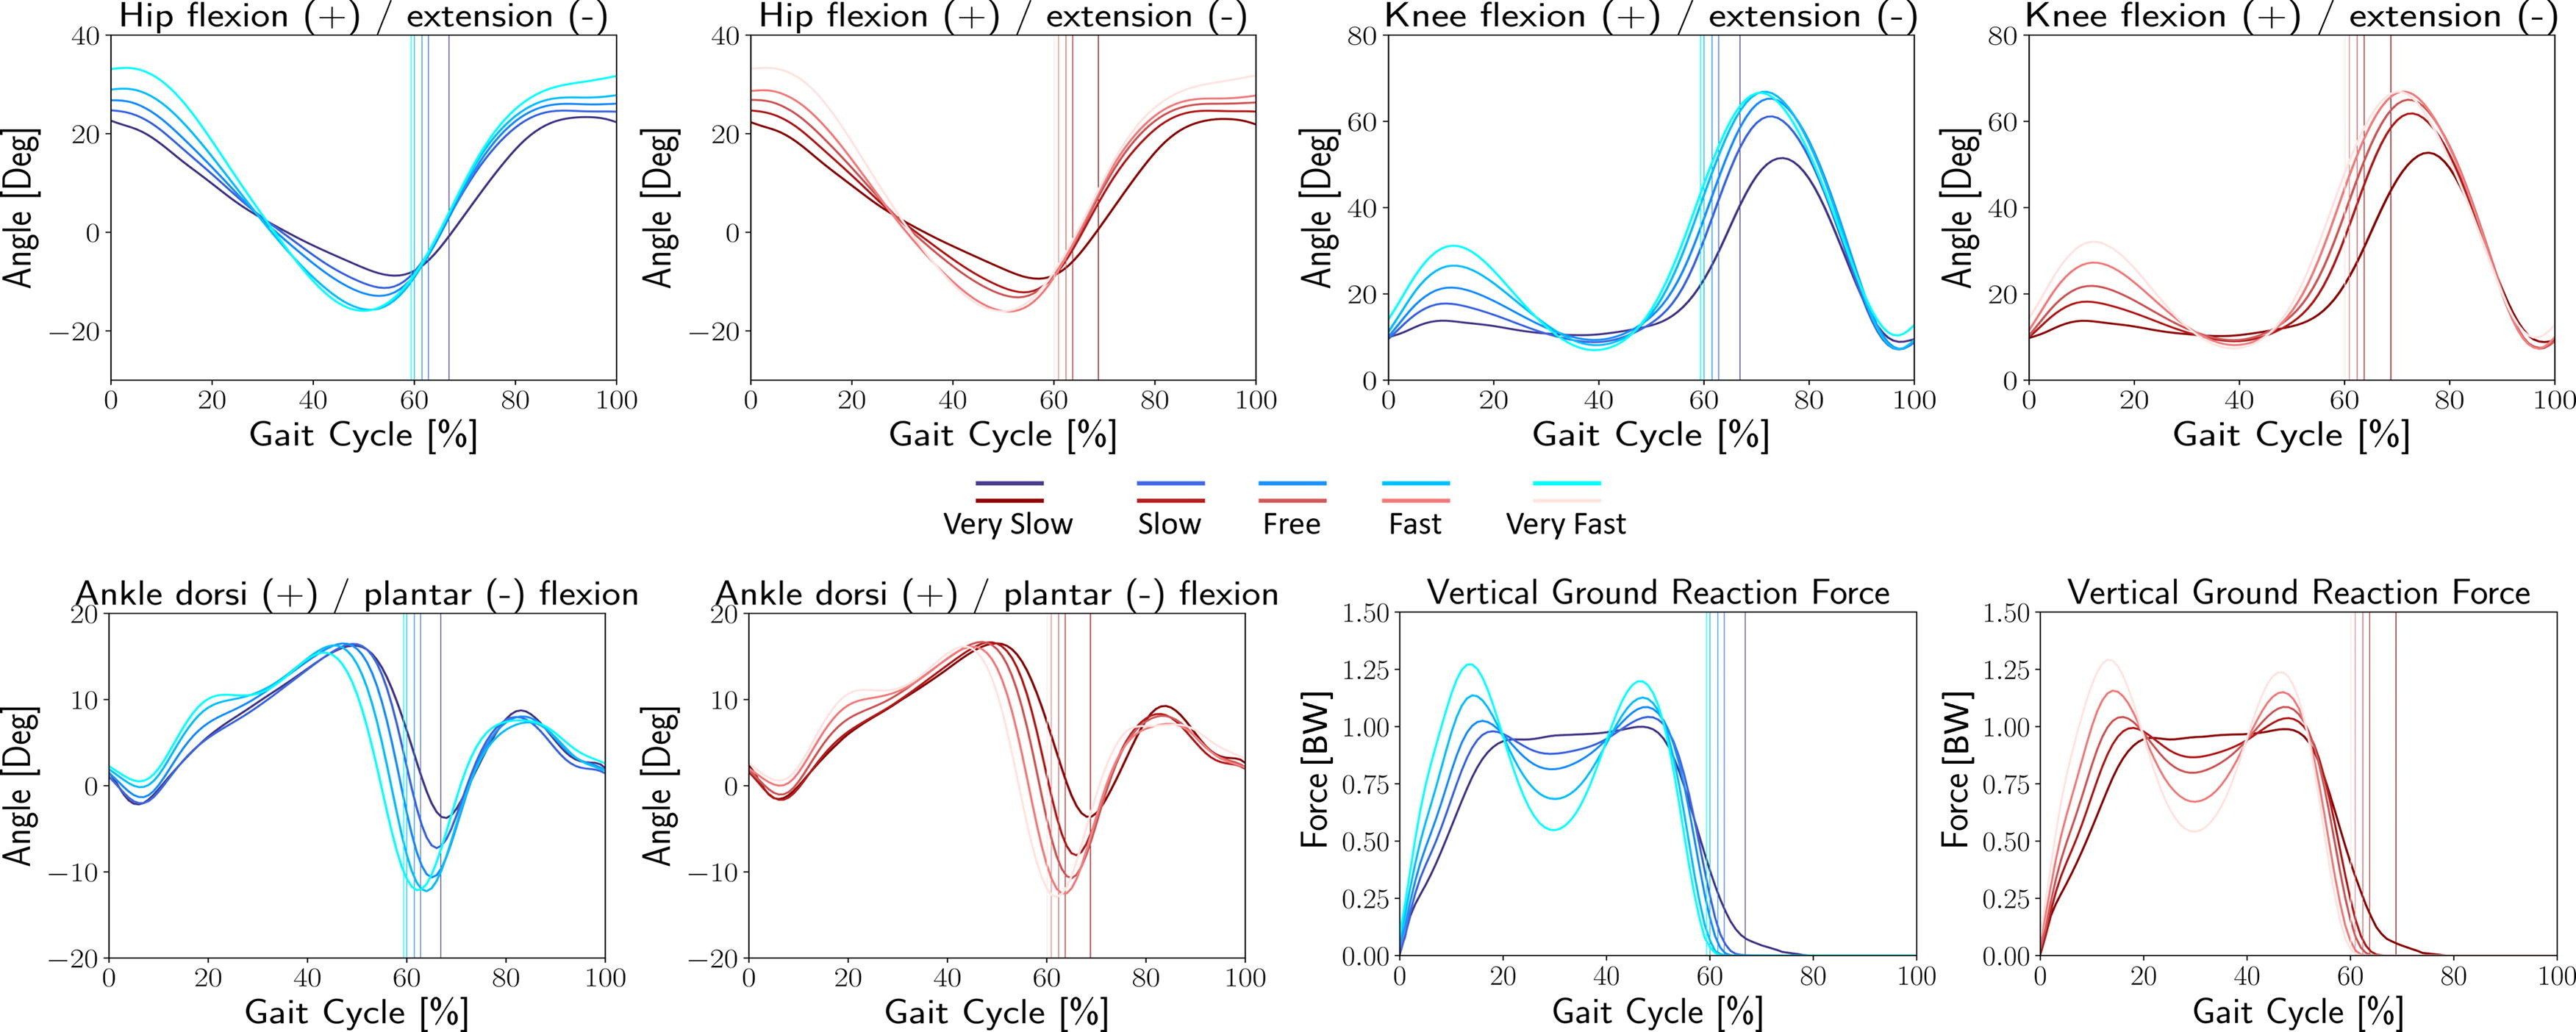

In [ ]:
from IPython.display import Image, display

display(Image("Figures/dimensionless.jpg"))

## 13.2 Generated IK Figure

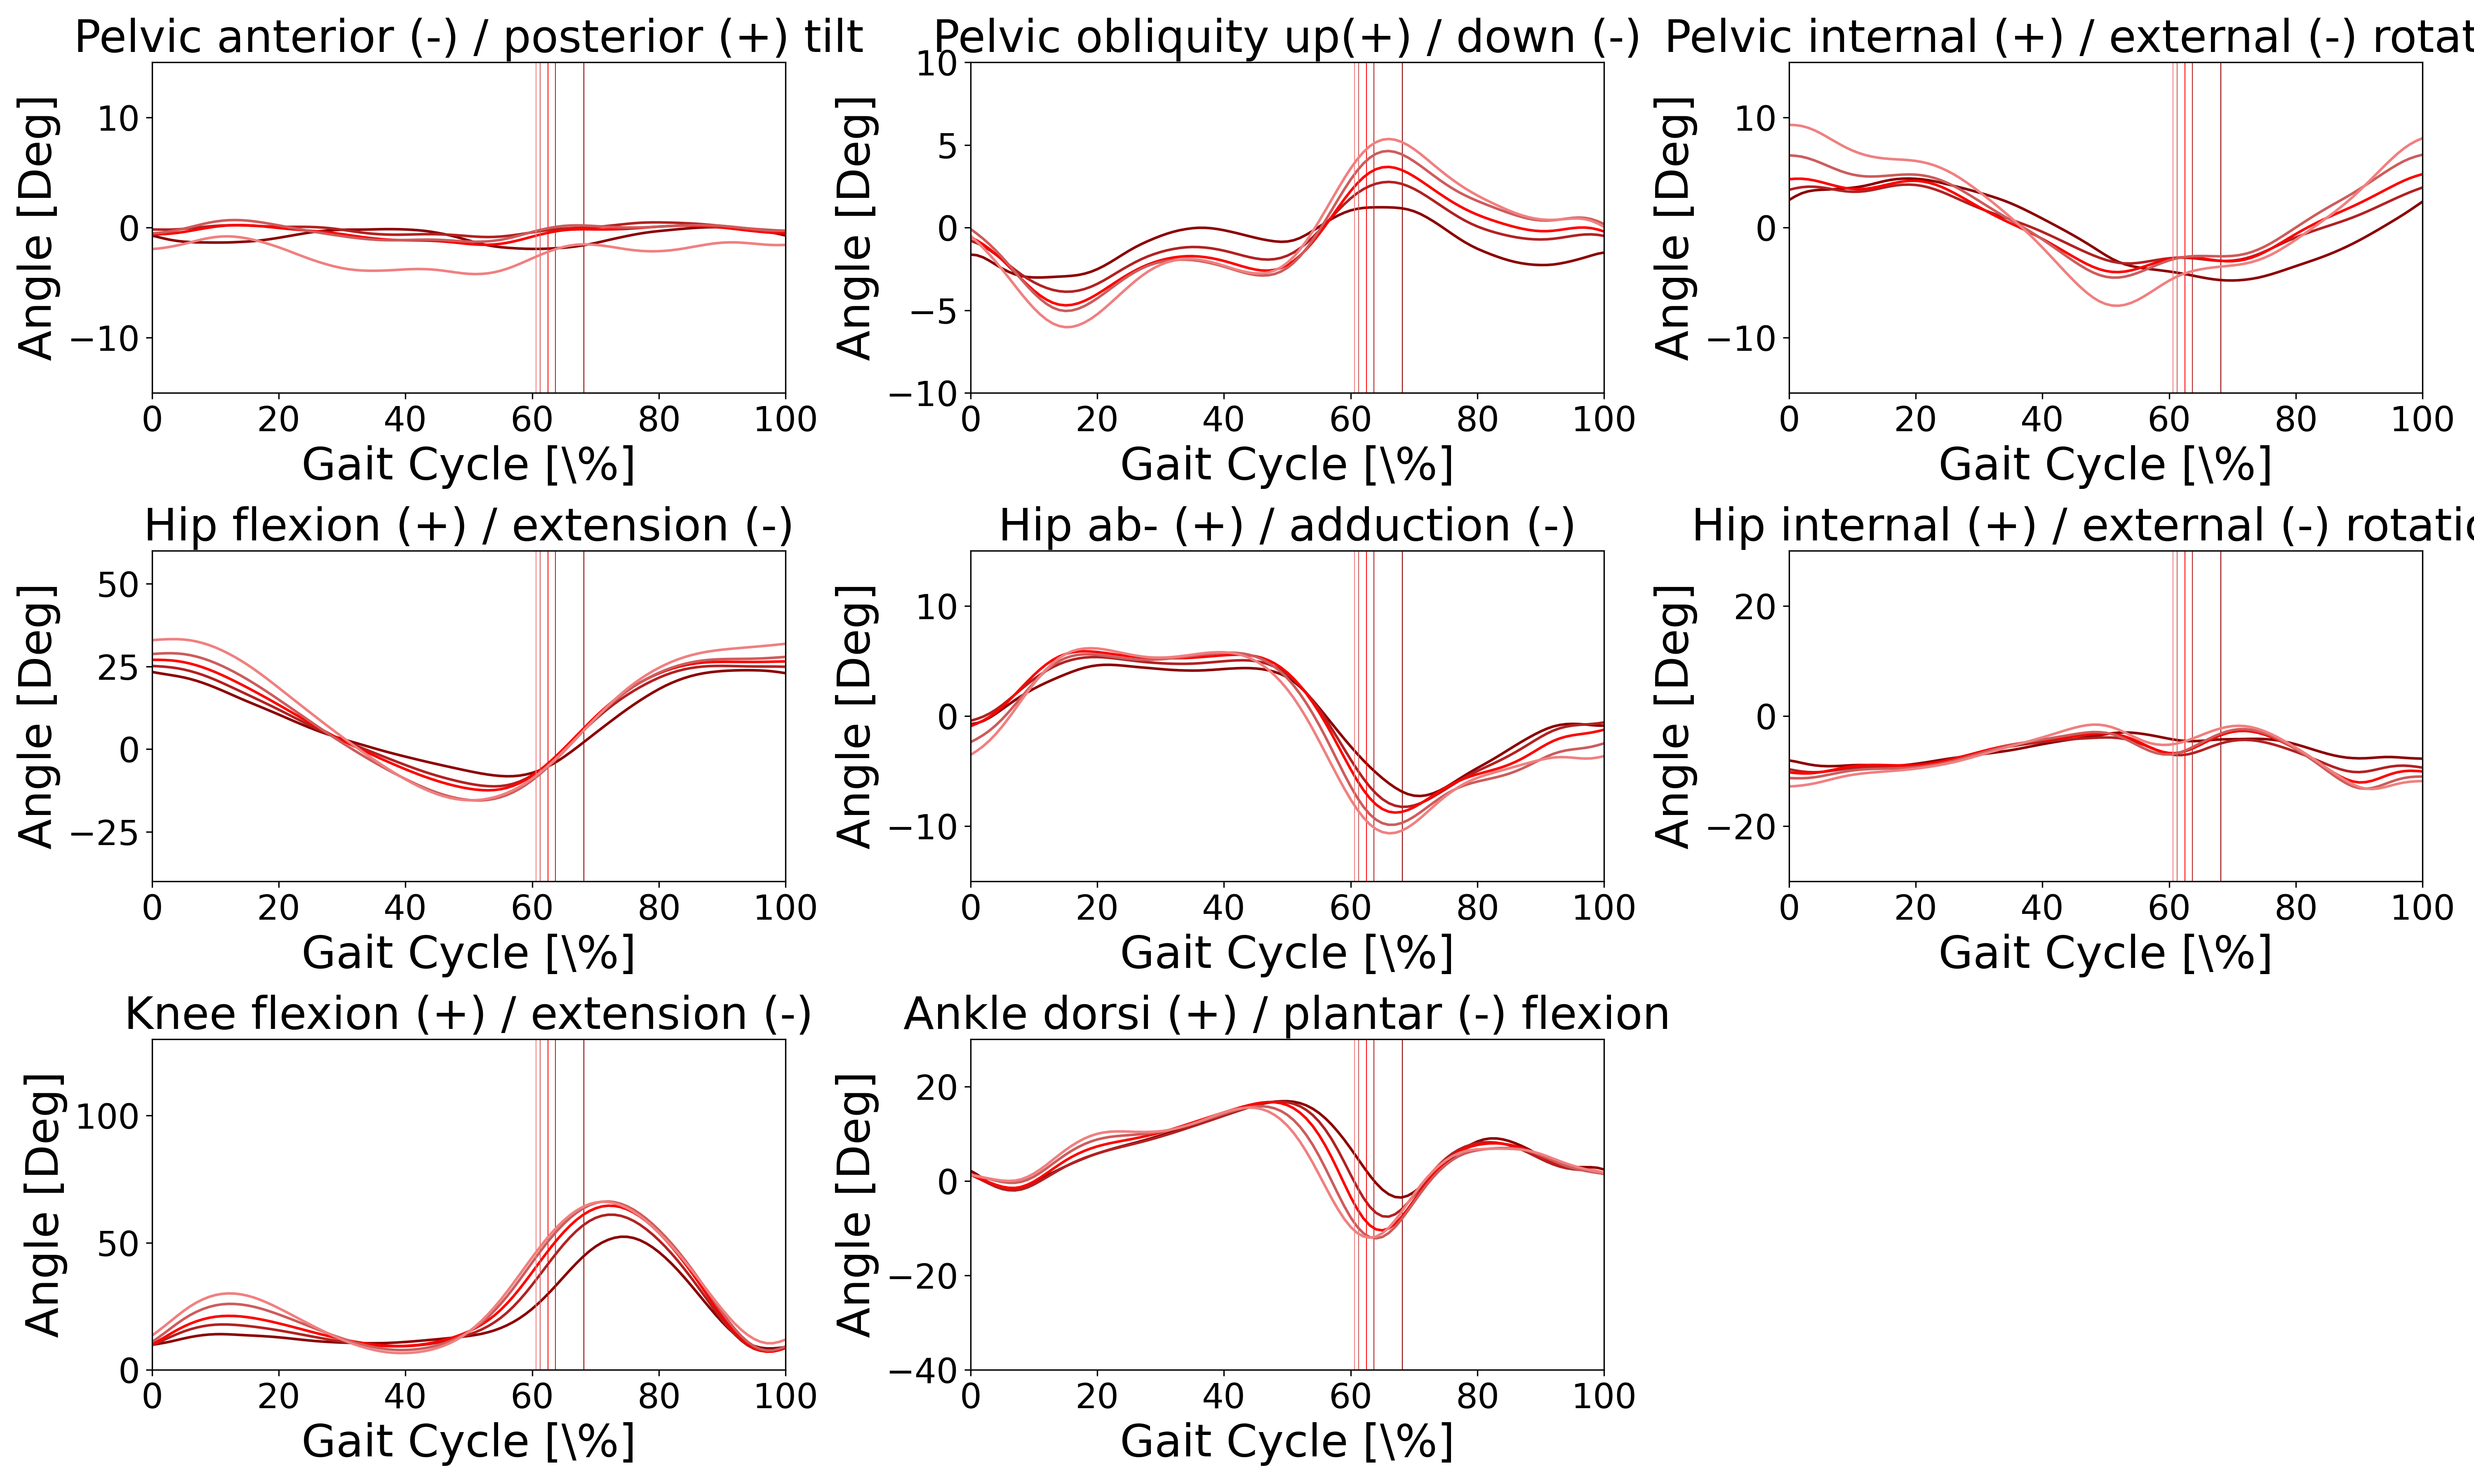

In [ ]:
display(Image("Figures/ik_generated.png"))


## 13.3 Generated GRF Figure

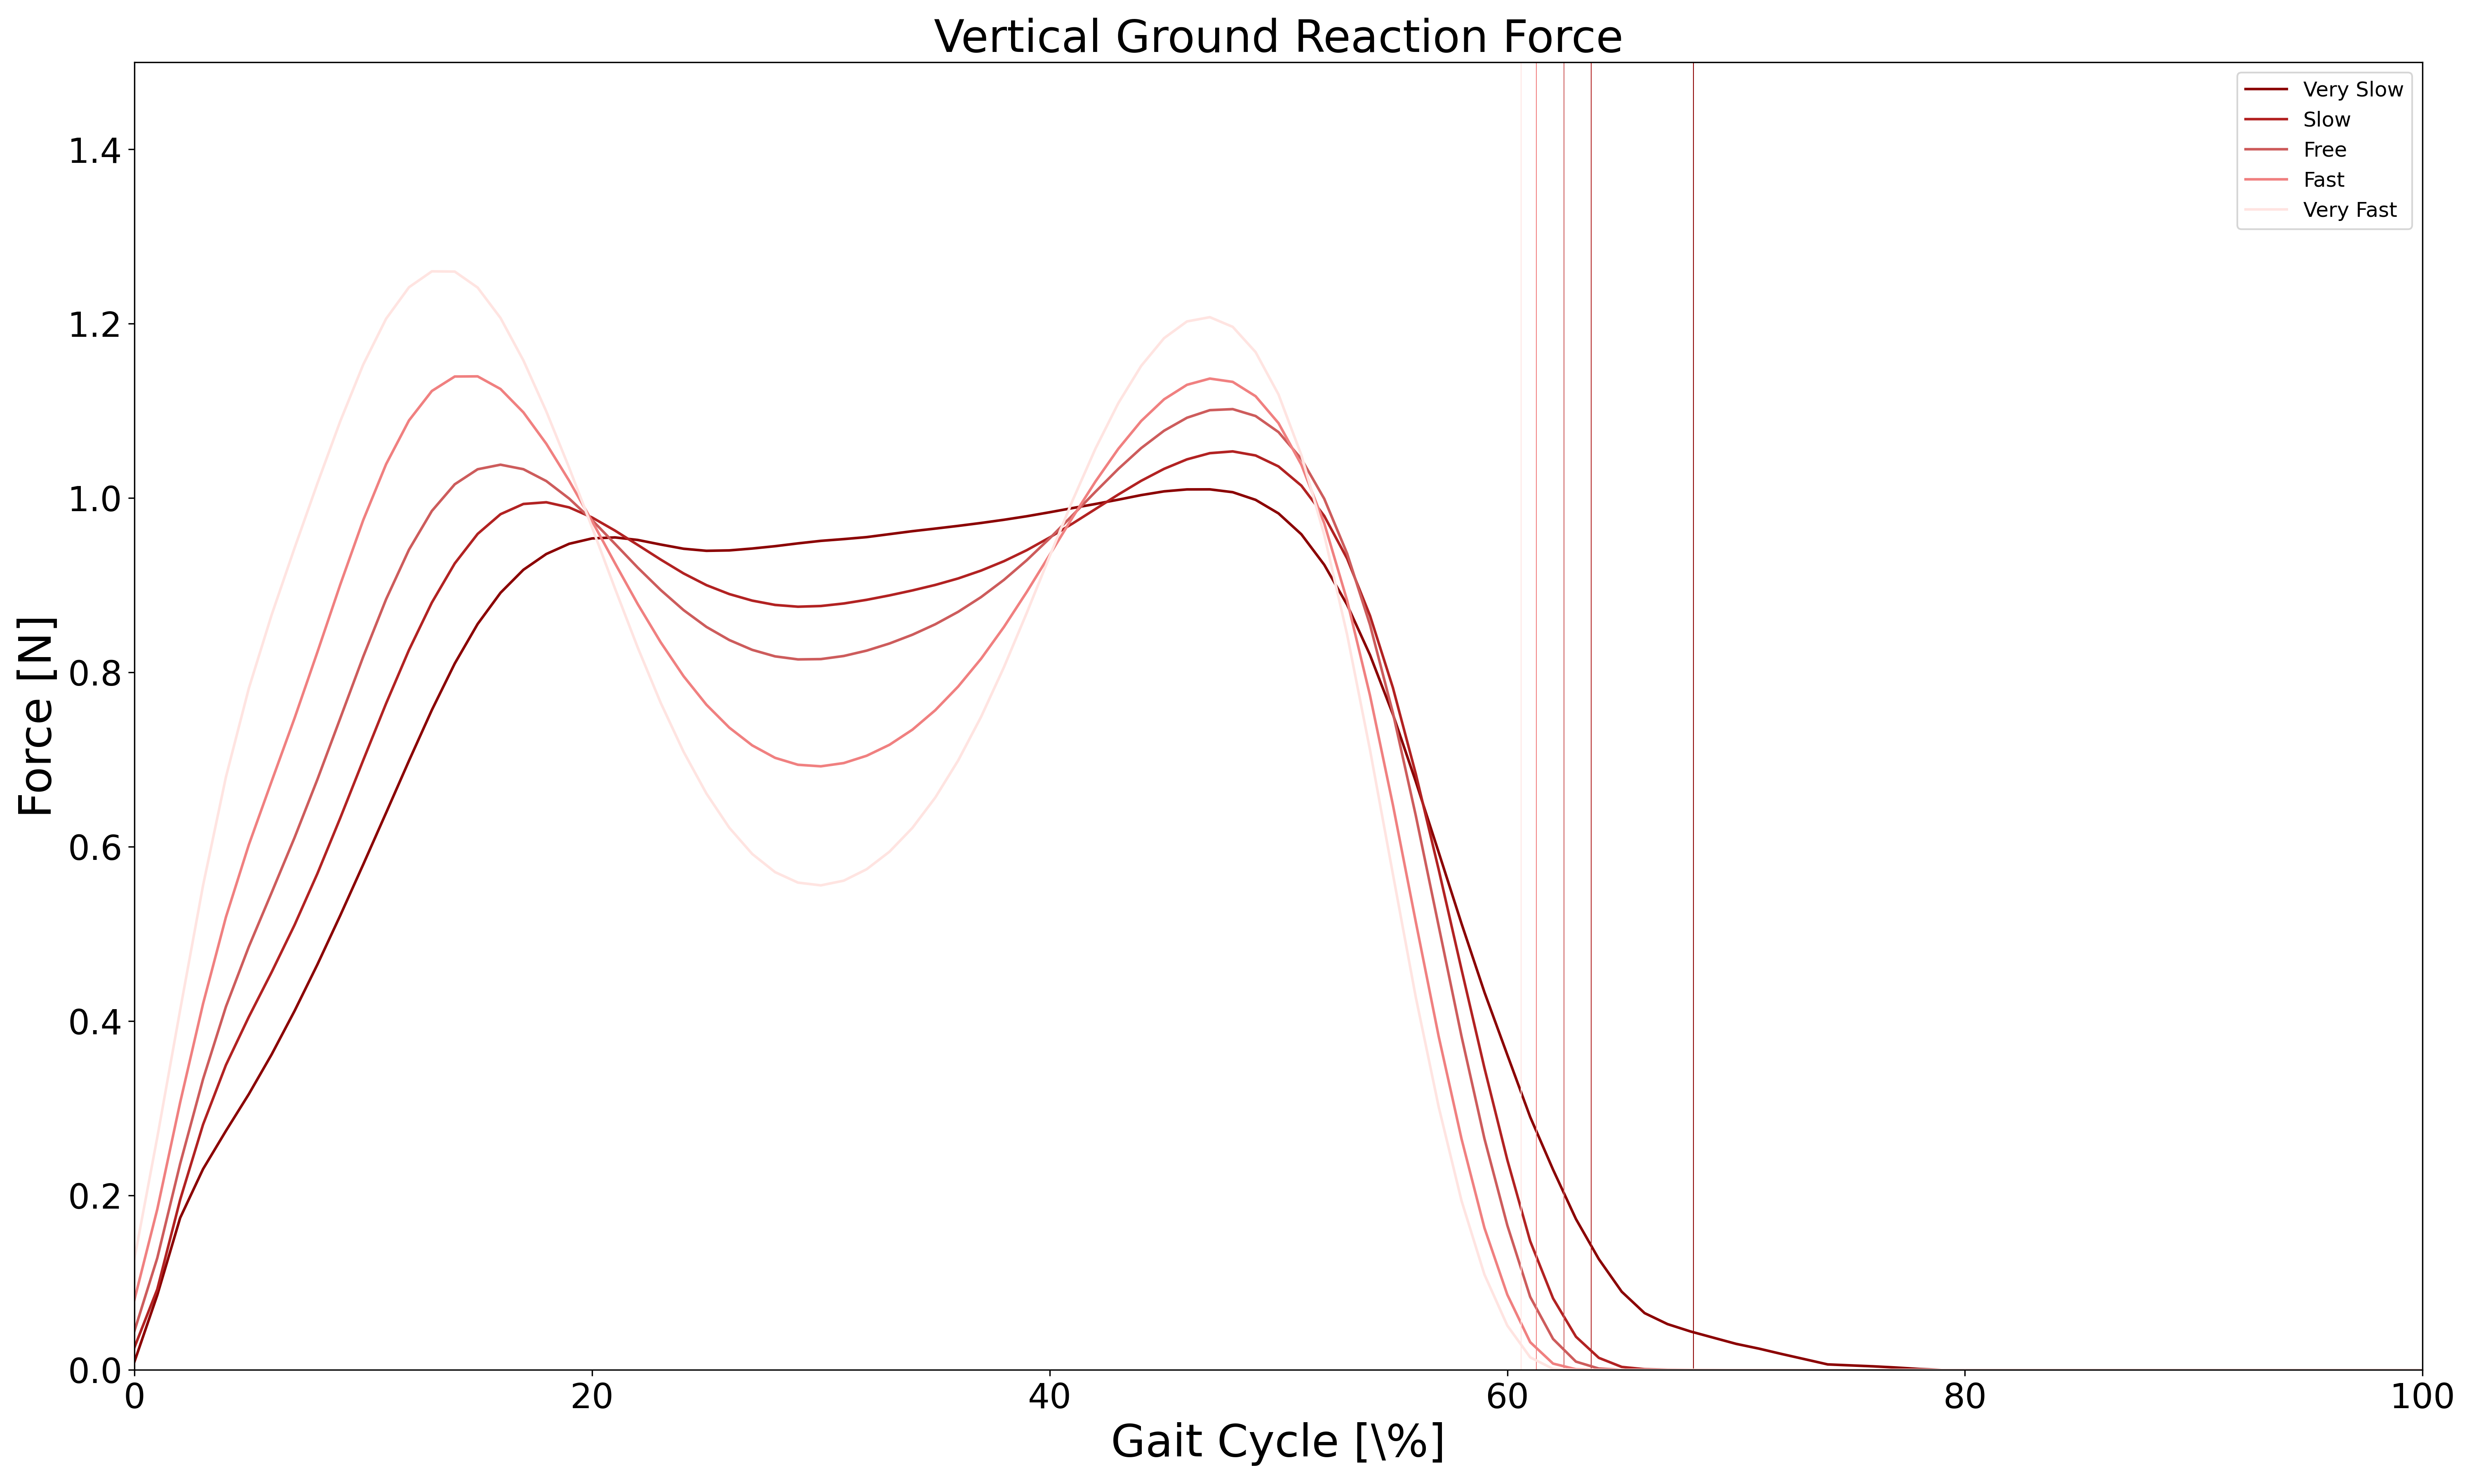

In [ ]:
display(Image("Figures/grf_vertical_generated.png"))

## 13.4 Visual Inspection Notes

The generated figures were visually inspected after reproduction.

### Observations

* All figure generation scripts executed successfully in Google Colab.
* The generated figures were successfully saved and displayed.
* The reproduced figures show the expected gait trajectories, joint kinematics, and ground reaction force patterns.
* After applying the Colab compatibility fixes, the figures became readable and suitable for inspection.
* No additional modifications to the underlying analyses were required.

### Conclusion

The visual outputs generated during reproduction are consistent with the expected outputs of the original repository. Together with the successful execution of the evaluation scripts, this provides evidence that the reproduction workflow was completed successfully.

# 14. Reproducing Literature Findings

This section reproduces **Section 3.2** of the original paper.

The goal is to evaluate whether the trained Multi-cGAN can reproduce published biomechanical findings using only condition-matched synthetic datasets.

Three published datasets are reproduced:

- Bruening et al. (2015)
- Nigg et al. (1994)
- Weinhandl et al. (2017)

The generated synthetic data are compared with the published results reported in the original studies.

In [14]:
!python previous_papers.py

#####################################
########## NIGG ET AL 1994 ##########
#####################################


AGE 20-39
Ankle Dorsiflexion ROM:
------------------------------
Males: 27.5±4.2 deg
Females: 29.6±4.1 deg
Diff: 2.0 deg
p: p=0.00


AGE 70-79
Ankle Dorsiflexion ROM:
------------------------------
Males: 25.8±4.7 deg
Females: 24.8±4.7 deg
Diff: 0.9 deg
p: p=0.07


Gender Differences (male vs female for all ages combined)
First Peak:
------------------------------
Males: 117.7±12.7 %BW
Females: 114.9±10.0 %BW
Difference: 2.7 %BW
p: p=0.00


Second Peak:
------------------------------
Males: 106.8±12.8 %BW
Females: 109.1±8.0 %BW
Diff: 2.3 %BW
p: p=0.00



##########################################
########## BRUENING ET AL 2015 ##########
##########################################


Angle               Female ROM     Male ROM       Diff      p         
Pelvic Tilt         4.4±0.4        3.3±0.4        1.2       0.000     
Pelvic Obliquity    12.2±0.6       8.4±0.6        3

## 14.1 Results

The synthetic datasets successfully reproduced several established biomechanical findings reported in previous gait studies.

Specifically, the analyses reproduced:

- age- and sex-related ankle dorsiflexion differences (Nigg et al., 1994),
- sex differences in lower-limb kinematics (Bruening et al., 2015),
- walking speed effects on ground reaction forces (Weinhandl et al., 2017).

The reproduced statistical results are consistent with the published literature, indicating that the generated datasets preserve important physiological relationships beyond simple signal similarity.

# 15. Dynamic Consistency Analysis

## Objective

This section reproduces the dynamic consistency analysis reported in the original paper.

The analysis compares residual pelvis forces and moments obtained from inverse dynamics for experimental and synthetic gait trials. This evaluates whether the synthetic mocap data remain dynamically plausible after being transformed back from normalized gait-cycle time to the original time domain.

The original paper reports this analysis mainly for WS-cGAN and Multi-cGAN, because these models include walking speed information and can therefore support time denormalization.

In [15]:
!head -60 dynamical_consistency.py

# -*- coding: utf-8 -*-
"""

Author:   Metin Bicer
email:    m.bicer19@imperial.ac.uk

reproduces results for the dynamical inconsistency analysis in the paper

"""
import numpy as np
import matplotlib.pyplot as plt
import spm1d
import os
from utils import read_dataframes


def diff_dynamic_cons(models, percent_to, plot, save,
                      exp_color='b', synthetic_color='r', spm_color='grey',
                      save_name='SPM', plot_individual=False, alpha=0.2):
    """
    compares dynamical inconsistencies (forces and moments on pelvis
                                        calculated by ID)

    Args:
        models (list): generative model names (has to have results saved
                                               on 'Results/opensim').
        percent_to (bool): True or False to express differences in % of stance
                            and swing phases.
        plot (bool): True or False to plot
        save (bool): True or False to save the plot
        exp_

In [16]:
!tail -40 dynamical_consistency.py

                    # indicate significant difference regions
                    for cluster in ti.clusters:
                        ax.axvspan(cluster.endpoints[0], cluster.endpoints[1],
                                   alpha=0.3, color=spm_color)
                    # set font sizes of ticks
                    ax.tick_params(axis='both', which='major', labelsize=15)
                    ax.tick_params(axis='both', which='minor', labelsize=12)
                    ax.set_xlim([0, 100])

        print('\n')
        # after plotting all
        if plot:
            # set y labels for first column
            axs[0].set_ylabel('Moment [Nm]', fontsize=25)
            axs[3].set_ylabel('Force [N]', fontsize=25)
            # set x label for columns
            for i in [3, 4, 5]: axs[i].set_xlabel('Gait Cycle [\%]', fontsize=25)
            # get legend handles and labels
            handles, labels = axs[0].get_legend_handles_labels()
            labels, ids = np.unique(labels, return_i

In [17]:
!python dynamical_consistency.py

/content/generative-mocap/dynamical_consistency.py:142: SyntaxWarning: invalid escape sequence '\%'
  for i in [3, 4, 5]: axs[i].set_xlabel('Gait Cycle [\%]', fontsize=25)
/content/generative-mocap/utils.py:486: SyntaxWarning: invalid escape sequence '\%'
  for i in [4, 5, 9]: axs[i].set_xlabel('Gait Cycle [\%]', fontsize=25)
/content/generative-mocap/utils.py:598: SyntaxWarning: invalid escape sequence '\%'
  for ax in axs[2:]: ax.set_xlabel('Gait Cycle [\%]', fontsize=25)
wscgan
Force/Moment                             Before_TO                 After_TO
pelvis_tilt_moment                             2.5                     11.7
pelvis_list_moment                             9.6                     24.9
pelvis_rotation_moment                         1.6                      8.8
pelvis_tx_force                               25.3                     19.7
pelvis_ty_force                                5.5                     33.0
pelvis_tz_force                               31.1        

## 15.1 Results

The dynamic consistency analysis was successfully reproduced for the WS-cGAN and Multi-cGAN models.

Residual pelvis forces and moments were evaluated before and after time denormalization (TO). This analysis assesses whether restoring the original gait-cycle duration preserves biomechanically realistic inverse-dynamics solutions.

The reproduced results are consistent with the original paper and demonstrate that the generated synthetic gait remains dynamically plausible after temporal reconstruction.
